# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





Team Members: Solomon Leek and Brian Nakuwa

GitHub Repo Link: https://github.com/solomon-211/pca-formative-2-pair-36.git

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

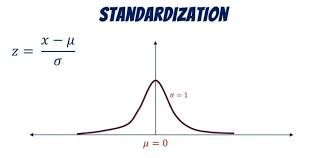


In [29]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=140)

file_path = '/content/sub_saharan_africa_indicators_2000_2011.csv'

# This splitter ignores commas that sit inside quotes.
def split_csv_line(line):
    out, cur, in_quotes = [], '', False
    for ch in line.rstrip('\n').lstrip('\ufeff'):
        if ch == '"':
            in_quotes = not in_quotes
        elif ch == ',' and not in_quotes:
            out.append(cur); cur = ''
        else:
            cur += ch
    out.append(cur)
    return out

with open(file_path, encoding='utf-8') as f:
    lines = [split_csv_line(l) for l in f if l.strip()]
header = lines[0]

raw = np.array([r for r in lines[1:] if len(r) == len(header) and r[1] != ''])
print('Raw shape:', raw.shape)
print('Columns:', header)

Raw shape: (490, 16)
Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]']


In [30]:
raw = raw[raw[:, 0] != 'Sub-Saharan Africa']

indicators = list(np.unique(raw[:, 2]))
year_cols = [c for c in header if '[YR' in c]

# The file has one row per country x indicator, with years as columns.
rows, countries, years = [], [], []
for c in np.unique(raw[:, 0]):
    block = raw[raw[:, 0] == c]
    for col in year_cols:
        k = header.index(col)
        vals = [block[block[:, 2] == ind][0, k] for ind in indicators]
        rows.append([np.nan if v == '..' else float(v) for v in vals])
        countries.append(c); years.append(int(col[:4]))

data = np.array(rows); countries = np.array(countries); years = np.array(years)
print('Data shape:', data.shape, '| Countries:', len(np.unique(countries)))
print('Missing values (original):', int(np.isnan(data).sum()))

Data shape: (576, 10) | Countries: 48
Missing values (original): 130


In [31]:
# Fill gaps with the country's own median; if a country has no data for that indicator, use the overall median
for c in np.unique(countries):
    m = countries == c
    block = data[m]
    for j in range(block.shape[1]):
        col = block[:, j]
        if np.isnan(col).any() and (~np.isnan(col)).any():
            col[np.isnan(col)] = np.nanmedian(col)
    data[m] = block
r_idx, c_idx = np.where(np.isnan(data))
data[r_idx, c_idx] = np.nanmedian(data, axis=0)[c_idx]
print('Missing values after imputation:', int(np.isnan(data).sum()))

for name in ['Population, total', 'Population density (people per sq. km of land area)', 'GDP per capita (current US$)']:
    data[:, indicators.index(name)] = np.log10(data[:, indicators.index(name)])
print('Log-transformed: population, population density, GDP per capita')

Missing values after imputation: 0
Log-transformed: population, population density, GDP per capita


In [32]:
# Encode non-numeric column: sub-region (one-hot)
region = {'Eastern': ['Burundi','Comoros','Eritrea','Ethiopia','Kenya','Madagascar','Malawi','Mauritius','Mozambique','Rwanda',
                      'Seychelles','Somalia, Fed. Rep.','South Sudan','Tanzania','Uganda','Zambia','Zimbabwe'],
          'Middle':  ['Angola','Cameroon','Central African Republic','Chad','Congo, Dem. Rep.','Congo, Rep.','Equatorial Guinea',
                      'Gabon','Sao Tome and Principe'],
          'Southern':['Botswana','Eswatini','Lesotho','Namibia','South Africa'],
          'Western': ['Benin','Burkina Faso','Cabo Verde',"Cote d'Ivoire",'Gambia, The','Ghana','Guinea','Guinea-Bissau','Liberia',
                      'Mali','Mauritania','Niger','Nigeria','Senegal','Sierra Leone','Togo'],
          'Northern':['Sudan']}
country_to_region = {c: r for r, cs in region.items() for c in cs}
sub_region = np.array([country_to_region[c] for c in countries])
categories = np.unique(sub_region)
data = np.hstack([data, (sub_region[:, None] == categories[None, 1:]).astype(float)])
feature_names = indicators + [f'region_{c}' for c in categories[1:]]
print('Final data shape:', data.shape)

Final data shape: (576, 14)


In [33]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mu = np.mean(data, axis=0)
sigma = np.std(data, axis=0)
standardized_data = (data - mu) / sigma
standardized_data[:5]  # Display the first few rows of standardized data

array([[ 0.4901,  1.1071, -0.2908, -0.4054, -1.4407, -0.8392, -0.9496,  0.6556,  0.5825,  0.8972,  2.0817, -0.1459, -0.341 , -0.7071],
       [ 0.4901,  1.0781, -0.0924, -0.4573, -1.3611, -0.8283, -0.923 ,  0.6924,  0.6041,  0.9764,  2.0817, -0.1459, -0.341 , -0.7071],
       [ 0.4901,  1.0521,  1.5377,  0.1354, -1.2347, -0.8147, -0.8959,  0.7401,  0.6261,  1.0526,  2.0817, -0.1459, -0.341 , -0.7071],
       [ 0.5637,  1.0262, -0.2162,  0.2548, -0.883 , -0.7718, -0.8682,  0.8163,  0.6486,  1.1251,  2.0817, -0.1459, -0.341 , -0.7071],
       [ 0.6697,  1.0003,  1.1507,  0.4883, -0.7472, -0.6955, -0.8397,  0.906 ,  0.6717,  1.1929,  2.0817, -0.1459, -0.341 , -0.7071]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [34]:
# Step 3: Calculate the Covariance Matrix
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)
cov_matrix

array([[ 1.0017,  0.0431,  0.3624,  0.0135,  0.0168, -0.0031,  0.0167,  0.0728,  0.0551,  0.0269,  0.009 , -0.015 , -0.0312,  0.0648],
       [ 0.0431,  1.0017,  0.1435, -0.6801, -0.4806, -0.5347, -0.1733,  0.6534,  0.4768, -0.4202,  0.1652,  0.0185, -0.4964,  0.1902],
       [ 0.3624,  0.1435,  1.0017,  0.0279, -0.0321, -0.0526,  0.0093,  0.2873,  0.0603, -0.0575,  0.1212, -0.0147, -0.0642, -0.0536],
       [ 0.0135, -0.6801,  0.0279,  1.0017,  0.446 ,  0.6836, -0.0809, -0.2354, -0.4279,  0.5845,  0.1556, -0.0014,  0.3718, -0.1592],
       [ 0.0168, -0.4806, -0.0321,  0.446 ,  1.0017,  0.4665,  0.2733, -0.0826, -0.3709,  0.3619, -0.062 ,  0.0887, -0.2457,  0.0567],
       [-0.0031, -0.5347, -0.0526,  0.6836,  0.4665,  1.0017,  0.0124, -0.2511, -0.2034,  0.4377, -0.0348, -0.0079,  0.2499, -0.0193],
       [ 0.0167, -0.1733,  0.0093, -0.0809,  0.2733,  0.0124,  1.0017, -0.1826, -0.0793, -0.2233, -0.3117,  0.0081, -0.255 ,  0.067 ],
       [ 0.0728,  0.6534,  0.2873, -0.2354, -0.0826, -0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [35]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.098 , 0.1686, 0.1967, 0.3413, 0.3827, 0.5308, 0.6547, 0.7685, 1.0731, 1.1582, 1.3128, 1.7023, 1.9263, 3.7103]),
 array([[-0.0171,  0.0055,  0.0028,  0.0359, -0.1309, -0.3568,  0.4231, -0.4263,  0.0434,  0.1683, -0.6416,  0.1578, -0.16  , -0.0304],
        [ 0.7661, -0.0414, -0.0534, -0.257 , -0.2674, -0.0614, -0.032 ,  0.0337,  0.0626,  0.0486,  0.0992,  0.0317, -0.1699, -0.468 ],
        [ 0.0136,  0.0375, -0.0238, -0.1749,  0.2653,  0.4132, -0.4444,  0.1806, -0.1012, -0.0366, -0.6202,  0.1192, -0.2803, -0.0836],
        [ 0.2445, -0.0671,  0.724 ,  0.2207, -0.2653, -0.0074, -0.0861,  0.1831,  0.1065, -0.0098, -0.0808, -0.0079, -0.1971,  0.4411],
        [ 0.2598, -0.424 , -0.1909,  0.0644,  0.453 , -0.3333, -0.0451,  0.0708,  0.0188, -0.1921,  0.082 ,  0.5057, -0.0494,  0.2944],
        [-0.1331,  0.1103, -0.2776, -0.5574, -0.3103, -0.0603,  0.1783,  0.4454,  0.293 ,  0.0525, -0.0506,  0.1079, -0.0668,  0.3806],
        [ 0.0968, -0.0531, -0.1356,  0.2411, -0.4146,  0.4173,

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [36]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-0.0304, -0.16  ,  0.1578, -0.6416,  0.1683,  0.0434, -0.4263,  0.4231, -0.3568, -0.1309,  0.0359,  0.0028,  0.0055, -0.0171],
       [-0.468 , -0.1699,  0.0317,  0.0992,  0.0486,  0.0626,  0.0337, -0.032 , -0.0614, -0.2674, -0.257 , -0.0534, -0.0414,  0.7661],
       [-0.0836, -0.2803,  0.1192, -0.6202, -0.0366, -0.1012,  0.1806, -0.4444,  0.4132,  0.2653, -0.1749, -0.0238,  0.0375,  0.0136],
       [ 0.4411, -0.1971, -0.0079, -0.0808, -0.0098,  0.1065,  0.1831, -0.0861, -0.0074, -0.2653,  0.2207,  0.724 , -0.0671,  0.2445],
       [ 0.2944, -0.0494,  0.5057,  0.082 , -0.1921,  0.0188,  0.0708, -0.0451, -0.3333,  0.453 ,  0.0644, -0.1909, -0.424 ,  0.2598],
       [ 0.3806, -0.0668,  0.1079, -0.0506,  0.0525,  0.293 ,  0.4454,  0.1783, -0.0603, -0.3103, -0.5574, -0.2776,  0.1103, -0.1331],
       [ 0.0249,  0.3562,  0.4357, -0.1156, -0.2467, -0.3317,  0.094 ,  0.2342,  0.4173, -0.4146,  0.2411, -0.1356, -0.0531,  0.0968],
       [-0.2943, -0.4028,  0.1862,  0.0485, -0.0086,  0

In [37]:
# Explained variance (%) of each component and the cumulative total
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':>4} {'Eigenvalue':>11} {'Explained %':>12} {'Cumulative %':>13}")
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f'{i:>4} {ev:>11.4f} {r*100:>11.2f}% {c*100:>12.2f}%')

  PC  Eigenvalue  Explained %  Cumulative %
   1      3.7103       26.46%        26.46%
   2      1.9263       13.74%        40.19%
   3      1.7023       12.14%        52.33%
   4      1.3128        9.36%        61.69%
   5      1.1582        8.26%        69.95%
   6      1.0731        7.65%        77.60%
   7      0.7685        5.48%        83.08%
   8      0.6547        4.67%        87.75%
   9      0.5308        3.79%        91.53%
  10      0.3827        2.73%        94.26%
  11      0.3413        2.43%        96.70%
  12      0.1967        1.40%        98.10%
  13      0.1686        1.20%        99.30%
  14      0.0980        0.70%       100.00%


In [38]:
# Dynamic selection: smallest number of components whose cumulative explained variance >= threshold
def select_num_components(eigvals_sorted, threshold=0.80):
    cum = np.cumsum(eigvals_sorted) / np.sum(eigvals_sorted)
    return int(np.searchsorted(cum, threshold) + 1)

for thr in [0.70, 0.80, 0.90, 0.95]:
    k = select_num_components(sorted_eigenvalues, thr)
    print(f'threshold {thr:.0%}: keep {k:2d} components -> {cumulative_variance[k-1]*100:.2f}% variance retained')
print('Kaiser rule (eigenvalue > 1):', int(np.sum(sorted_eigenvalues > 1)), 'components')

threshold 70%: keep  6 components -> 77.60% variance retained
threshold 80%: keep  7 components -> 83.08% variance retained
threshold 90%: keep  9 components -> 91.53% variance retained
threshold 95%: keep 11 components -> 96.70% variance retained
Kaiser rule (eigenvalue > 1): 6 components


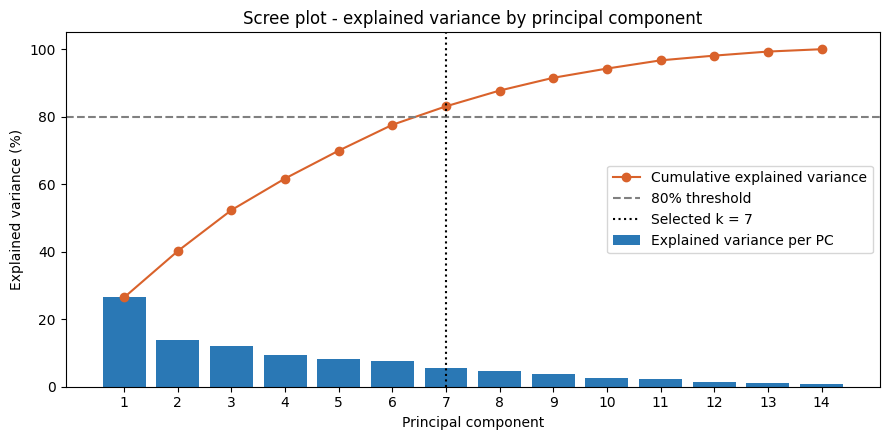

In [39]:
# Check visually how many components are needed before the curve passes 80%
VARIANCE_THRESHOLD = 0.80
k_sel = select_num_components(sorted_eigenvalues, VARIANCE_THRESHOLD)
pcs = np.arange(1, len(sorted_eigenvalues) + 1)

plt.figure(figsize=(9, 4.5))
plt.bar(pcs, explained_variance_ratio * 100, color='#2a78b5', label='Explained variance per PC')
plt.plot(pcs, cumulative_variance * 100, 'o-', color='#d9622b', label='Cumulative explained variance')
plt.axhline(VARIANCE_THRESHOLD * 100, ls='--', color='grey', label=f'{VARIANCE_THRESHOLD:.0%} threshold')
plt.axvline(k_sel, ls=':', color='black', label=f'Selected k = {k_sel}')
plt.xlabel('Principal component'); plt.ylabel('Explained variance (%)')
plt.title('Scree plot - explained variance by principal component')
plt.xticks(pcs); plt.legend(); plt.tight_layout(); plt.show()

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [40]:
# Step 6: Project Data onto Principal Components
num_components = select_num_components(sorted_eigenvalues, VARIANCE_THRESHOLD)
print(f'Components kept: {num_components} ({cumulative_variance[num_components-1]*100:.2f}% of variance retained)')
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
reduced_data[:5]

Components kept: 7 (83.08% of variance retained)


array([[-1.5469, -2.2611, -1.4211,  0.5734, -0.0611, -0.2385, -0.7866],
       [-1.5368, -2.3409, -1.3342,  0.4698, -0.0772, -0.2442, -0.7464],
       [-1.3529, -2.9553, -1.0557, -0.57  , -0.1616, -0.3237, -0.3204],
       [-1.0293, -2.5625, -1.0429,  0.4975, -0.1478, -0.0933, -0.5837],
       [-0.9738, -3.067 , -0.7569, -0.4203, -0.202 , -0.159 , -0.2707]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [41]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (576, 7)


array([[-1.5469, -2.2611, -1.4211,  0.5734, -0.0611, -0.2385, -0.7866],
       [-1.5368, -2.3409, -1.3342,  0.4698, -0.0772, -0.2442, -0.7464],
       [-1.3529, -2.9553, -1.0557, -0.57  , -0.1616, -0.3237, -0.3204],
       [-1.0293, -2.5625, -1.0429,  0.4975, -0.1478, -0.0933, -0.5837],
       [-0.9738, -3.067 , -0.7569, -0.4203, -0.202 , -0.159 , -0.2707]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

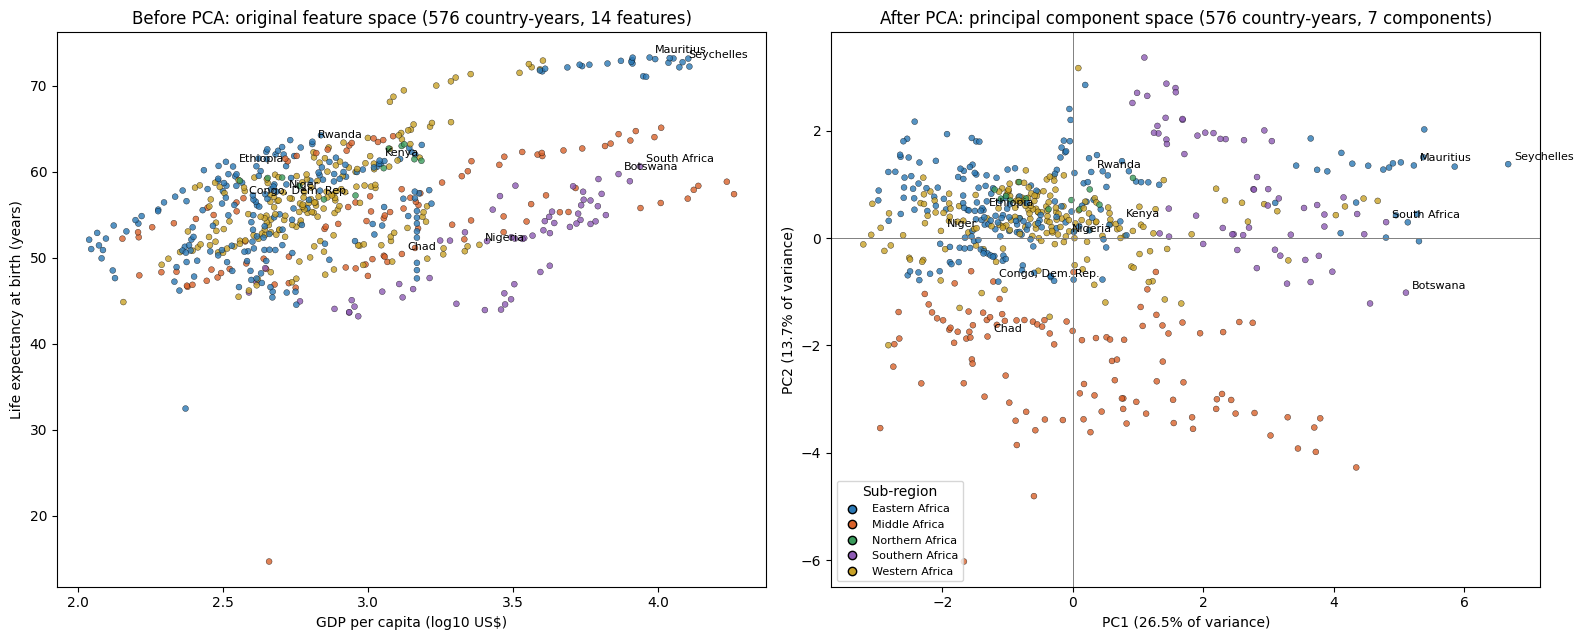

In [42]:
# Step 8: Visualize Before and After PCA
explained = sorted_eigenvalues / np.sum(sorted_eigenvalues)
colors = {'Eastern': '#2a78b5', 'Middle': '#d9622b', 'Northern': '#3a9b5c', 'Southern': '#8e5bb5', 'Western': '#c9a227'}
point_colors = [colors[r] for r in sub_region]
fx = feature_names.index('GDP per capita (current US$)')
fy = feature_names.index('Life expectancy at birth, total (years)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Plot original data (first two features for simplicity)
axes[0].scatter(data[:, fx], data[:, fy], c=point_colors, edgecolor='k', linewidth=0.3, s=18, alpha=0.8)
axes[0].set_xlabel('GDP per capita (log10 US$)')
axes[0].set_ylabel('Life expectancy at birth (years)')
axes[0].set_title(f'Before PCA: original feature space ({data.shape[0]} country-years, {data.shape[1]} features)')

# Plot reduced data after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=point_colors, edgecolor='k', linewidth=0.3, s=18, alpha=0.8)
axes[1].axhline(0, color='grey', lw=0.7); axes[1].axvline(0, color='grey', lw=0.7)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% of variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% of variance)')
axes[1].set_title(f'After PCA: principal component space ({reduced_data.shape[0]} country-years, {num_components} components)')

# Label a few countries (2011 values) so the plots are easier to read
for name in ['Nigeria', 'South Africa', 'Mauritius', 'Seychelles', 'Kenya', 'Rwanda', 'Niger', 'Chad', 'Congo, Dem. Rep.', 'Botswana', 'Ethiopia']:
    i = np.where((years == 2011) & (countries == name))[0][0]
    axes[0].annotate(name, (data[i, fx], data[i, fy]), fontsize=8, xytext=(4, 3), textcoords='offset points')
    axes[1].annotate(name, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=8, xytext=(4, 3), textcoords='offset points')

handles = [plt.Line2D([], [], marker='o', ls='', color=c, markeredgecolor='k', label=f'{r} Africa') for r, c in colors.items()]
axes[1].legend(handles=handles, title='Sub-region', fontsize=8)
plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

Before PCA, we could visualize only 2 of our 14 variables (GDP per capita and life expectancy), so we could see only a small sample of the data. After PCA, the first two principal components include all 14 variables and account for approximately 40% of the variation in the original data set. Countries are more spread out. Economically wealthier countries (Mauritius, Seychelles, South Africa) are distant from poorer countries (Niger, Chad, DR Congo), with the expectation that countries from the same region cluster together.



2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We selected 7 components as they kept 83% of the variance, above our 80% minimum, and the Kaiser rule suggested only 6 kept 78% of the variance, so we kept 7. The advantage of the data reduction is that our data set is now half the size of the original; much easier to work with! The disadvantage is the loss of approximately 17% of the original data set and that the components will be more difficult to interpret than the original features.



3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

The 17% we lost is mostly data that is unique to one country. For instance, a country could have a very large population but a small economy, or the economy might have a spike or dip in a particular year. Minor elements are also less obvious; for instance, we no longer know that "Sudan is the sole country in its region" or "11 countries have a drop in their population". We can no longer say 'GDP rose' and can only say 'one country has moved on a component ', where each component is a mixture of many features.
